# 🤖 Context-Aware RAG Chatbot with LangChain

**Task 4: Context-Aware Chatbot Using LangChain + RAG**

This notebook builds a production-ready conversational chatbot that:
- ✅ Uses **RAG (Retrieval-Augmented Generation)** with FAISS vector store
- ✅ Implements **context memory** for multi-turn conversations
- ✅ Retrieves answers from a **vectorized document store**
- ✅ Deploys via **Streamlit** (with ngrok tunnel for Colab)

---
### Architecture Overview
```
User Query
    │
    ▼
Conversation Memory (ConversationBufferWindowMemory)
    │
    ▼
Query Embedding (HuggingFace / OpenAI)
    │
    ▼
FAISS Vector Store ──► Top-K Relevant Chunks
    │
    ▼
LLM (OpenAI / HuggingFace) + Context + History
    │
    ▼
Final Answer
```

## 📦 Step 1: Install Dependencies

In [20]:
# Install all required packages
!pip install -q langchain langchain-community langchain-openai
!pip install -q faiss-cpu sentence-transformers
!pip install -q streamlit pyngrok
!pip install -q tiktoken pypdf wikipedia
!pip install -q chromadb  # Alternative vector store
!pip install langchain-core -q
!pip install langchain-text-splitters -q
!pip install langchain langchain-community langchain-core langchain-groq --upgrade -q

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.8 MB/s eta 0:00:00
✅ All packages installed successfully!


## 🔑 Step 2: Configure API Keys

In [3]:
# ── Option B: ngrok (for Streamlit tunnel in Colab) ───────────────────────────
# Get your free token at: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = getpass("Enter your ngrok authtoken (press Enter to skip): ")
if NGROK_TOKEN:
    os.environ["NGROK_TOKEN"] = NGROK_TOKEN
    print("✅ ngrok configured")
else:
    print("ℹ️  Skipped ngrok — Streamlit will run without public URL")

Enter your ngrok authtoken (press Enter to skip): ··········
✅ ngrok configured


## 📚 Step 3: Build the Knowledge Base

We support **three corpus options** — choose the one that fits your use case.

In [10]:
import wikipedia
from langchain_core.documents import Document

# ════════════════════════════════════════════════════════════
#  CORPUS OPTION 1: Wikipedia Pages (default — no setup needed)
# ════════════════════════════════════════════════════════════
WIKIPEDIA_TOPICS = [
    "Artificial intelligence",
    "Machine learning",
    "Deep learning",
    "Natural language processing",
    "Large language model",
    "Transformer (machine learning model)",
    "Retrieval-augmented generation",
    "LangChain",
]

def load_wikipedia_corpus(topics):
    """Load Wikipedia articles as LangChain Documents."""
    docs = []
    for topic in topics:
        try:
            page = wikipedia.page(topic, auto_suggest=False)
            doc = Document(
                page_content=page.content[:8000],  # First 8k chars per article
                metadata={"source": "Wikipedia", "title": page.title, "url": page.url}
            )
            docs.append(doc)
            print(f"  ✅ Loaded: {page.title}")
        except Exception as e:
            print(f"  ⚠️  Skipped '{topic}': {e}")
    return docs


print(f"\n📄 Total documents loaded: {len(raw_docs)}")


📄 Total documents loaded: 10


## ✂️ Step 4: Chunk Documents

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Split documents into smaller overlapping chunks for better retrieval
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,        # Characters per chunk
    chunk_overlap=100,     # Overlap between chunks (preserves context at boundaries)
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]  # Prefer natural sentence breaks
)

chunks = text_splitter.split_documents(raw_docs)

print(f"📊 Chunking statistics:")
print(f"   Total chunks   : {len(chunks)}")
print(f"   Avg chunk size : {sum(len(c.page_content) for c in chunks) // len(chunks)} chars")
print(f"\n🔍 Sample chunk:")
print("-" * 60)
print(chunks[0].page_content[:300])
print(f"\nMetadata: {chunks[0].metadata}")

📊 Chunking statistics:
   Total chunks   : 199
   Avg chunk size : 308 chars

🔍 Sample chunk:
------------------------------------------------------------
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develo

Metadata: {'source': 'Wikipedia', 'title': 'Artificial intelligence', 'url': 'https://en.wikipedia.org/wiki/Artificial_intelligence'}


## 🧮 Step 5: Create Embeddings & FAISS Vector Store

In [15]:
from langchain_community.vectorstores import FAISS

# ── Configuration ─────────────────────────────────────────────────────────────
USE_OPENAI = False   # Set True only if you have an OpenAI API key

print("🔢 Initializing embedding model...")

if USE_OPENAI:
    # ── OpenAI Embeddings (1536-dim, most accurate) ───────────────────────────
    from langchain_openai import OpenAIEmbeddings
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    print("   Using: OpenAI text-embedding-3-small")
else:
    # ── Free HuggingFace Embeddings (runs locally on CPU) ─────────────────────
    from langchain_community.embeddings import HuggingFaceEmbeddings
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True}
    )
    print("   Using: sentence-transformers/all-MiniLM-L6-v2 (free, local)")

print("\n📥 Building FAISS index (this may take a minute)...")
vectorstore = FAISS.from_documents(chunks, embeddings)

# Save index to disk (persist between sessions)
vectorstore.save_local("faiss_index")
print(f"\n✅ FAISS index built and saved!")
print(f"   Vectors indexed: {vectorstore.index.ntotal}")

🔢 Initializing embedding model...


/tmp/ipykernel_4751/3803561436.py:16: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Using: sentence-transformers/all-MiniLM-L6-v2 (free, local)

📥 Building FAISS index (this may take a minute)...

✅ FAISS index built and saved!
   Vectors indexed: 199


## 🔍 Step 6: Test Retrieval

In [16]:
# Test the retriever with a sample query
retriever = vectorstore.as_retriever(
    search_type="mmr",           # Maximal Marginal Relevance (diverse results)
    search_kwargs={"k": 4, "fetch_k": 10}
)

test_query = "How does RAG reduce hallucinations in language models?"
results = retriever.invoke(test_query)

print(f"🔍 Query: {test_query}\n")
print(f"📄 Top {len(results)} retrieved chunks:\n")
for i, doc in enumerate(results, 1):
    print(f"[{i}] Source: {doc.metadata.get('title', 'Unknown')}")
    print(f"    {doc.page_content[:200]}...")
    print()

🔍 Query: How does RAG reduce hallucinations in language models?

📄 Top 4 retrieved chunks:

[1] Source: Retrieval-augmented generation
    . According to Ars Technica, "RAG is a way of improving LLM performance, in essence by blending the LLM process with a web search or other document look-up process to help LLMs stick to the facts." Th...

[2] Source: RAG Overview
    RAG (Retrieval-Augmented Generation) combines the strengths of retrieval-based
        and generative AI models. It works by first retrieving relevant documents from
        a knowledge base using sem...

[3] Source: Retrieval-augmented generation
    === RAG key stages ===...

[4] Source: Retrieval-augmented generation
    == Improvements ==
Improvements to the basic process above can be applied at different stages in the RAG flow....



## 🧠 Step 7: Setup LLM + Conversational RAG Chain

In [27]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
import os

# ── Initialize LLM ────────────────────────────────────────────────────────────
if USE_OPENAI:
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0.2, max_tokens=800)
    print("✅ LLM: OpenAI GPT-3.5-Turbo")
else:
    from langchain_groq import ChatGroq
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
    if not GROQ_API_KEY:
        from getpass import getpass
        GROQ_API_KEY = getpass("Enter Groq API key (free at console.groq.com): ")
        os.environ["GROQ_API_KEY"] = GROQ_API_KEY
    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.3, max_tokens=512)
    print("✅ LLM: LLaMA-3.1-8B via Groq")

# ── System Prompt ─────────────────────────────────────────────────────────────
QA_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a knowledgeable AI assistant with access to a curated
knowledge base. Answer questions accurately using the provided context.

Rules:
- Base your answer on the retrieved context when relevant
- If the context doesn't contain the answer, say so honestly
- Keep answers concise but complete (3-5 sentences by default)
- Reference sources when appropriate
- Remember the conversation history and refer to it when relevant

Context from knowledge base:
{context}"""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{question}"),
])

# ── Session store ─────────────────────────────────────────────────────────────
store = {}

def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

# ── Format docs helper ────────────────────────────────────────────────────────
def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

# ── LCEL RAG Chain (chat_history passed explicitly) ───────────────────────────
rag_chain = (
    RunnablePassthrough.assign(
        context=lambda x: format_docs(retriever.invoke(x["question"]))
    )
    | QA_PROMPT
    | llm
    | StrOutputParser()
)

# ── Wrap with message history ─────────────────────────────────────────────────
qa_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="question",
    history_messages_key="chat_history",
)

print("\n✅ Conversational RAG chain ready!")

✅ LLM: LLaMA-3.1-8B via Groq

✅ Conversational RAG chain ready!


## 💬 Step 8: Test the Chatbot in Notebook

In [28]:
SESSION_ID = "rag_session_1"

def chat(query, show_sources=True):
    """Send a message to the RAG chatbot and display the response."""
    print(f"\n{'─'*60}")
    print(f"👤 You: {query}")
    print(f"{'─'*60}")

    result = qa_chain.invoke(
        {"question": query},
        config={"configurable": {"session_id": SESSION_ID}}
    )

    print(f"🤖 Bot: {result}")

    if show_sources:
        history = get_session_history(SESSION_ID)
        print(f"\n💬 Messages in memory: {len(history.messages)}")

    return result


# ── Test Conversation ─────────────────────────────────────────────────────────
chat("What is Retrieval-Augmented Generation?")
chat("How does it differ from traditional LLMs?")
chat("What are the main components of LangChain?")
chat("Can you summarize what we've discussed so far?")


────────────────────────────────────────────────────────────
👤 You: What is Retrieval-Augmented Generation?
────────────────────────────────────────────────────────────
🤖 Bot: Retrieval-Augmented Generation (RAG) is a method that enhances large language models (LLMs) by incorporating an information-retrieval mechanism. This allows models to access and utilize additional data beyond their original training set, making them more accurate and up-to-date. According to a 2020 paper, RAG combines a parametric language model with a non-parametric external memory accessed through retrieval at inference time.

💬 Messages in memory: 2

────────────────────────────────────────────────────────────
👤 You: How does it differ from traditional LLMs?
────────────────────────────────────────────────────────────
🤖 Bot: Retrieval-Augmented Generation (RAG) differs from traditional Large Language Models (LLMs) in that it incorporates an external memory that can be accessed through retrieval at inference t

"We've discussed the following topics:\n\n1. I provided context about an AI-generated response stating that Barack Obama was the first Muslim president, highlighting the limitations of large language models (LLMs) in understanding context.\n2. We talked about Retrieval-Augmented Generation (RAG), a method that enhances LLMs by incorporating an information-retrieval mechanism to access additional data beyond their original training set.\n3. I explained how RAG differs from traditional LLMs by allowing them to draw upon a larger knowledge base through retrieval at inference time.\n4. We discussed LangChain, a framework that provides abstractions for building applications powered by large language models, and I listed its main components, including Document Loaders, Text Splitters, Embeddings, Vector Stores, and Chains."

## 🔎 Step 9: Inspect Conversation Memory

In [30]:
# View the current conversation history stored in memory
print("📝 Current Conversation Memory:\n")

history = get_session_history(SESSION_ID).messages
for msg in history:
    role = "👤 Human" if msg.type == "human" else "🤖 AI"
    print(f"{role}: {msg.content[:200]}{'...' if len(msg.content) > 200 else ''}")
    print()

print(f"Total messages in memory: {len(history)}")

# Uncomment to clear memory and start fresh:
# store.clear()
# print("🧹 Memory cleared!")

📝 Current Conversation Memory:

👤 Human: What is Retrieval-Augmented Generation?

🤖 AI: Retrieval-Augmented Generation (RAG) is a method that enhances large language models (LLMs) by incorporating an information-retrieval mechanism. This allows models to access and utilize additional dat...

👤 Human: How does it differ from traditional LLMs?

🤖 AI: Retrieval-Augmented Generation (RAG) differs from traditional Large Language Models (LLMs) in that it incorporates an external memory that can be accessed through retrieval at inference time. This all...

👤 Human: What are the main components of LangChain?

🤖 AI: According to the provided context, the main components of LangChain include:

1. Document Loaders (ingest data)
2. Text Splitters (chunk documents)
3. Embeddings (convert text to vectors)
4. Vector St...

👤 Human: Can you summarize what we've discussed so far?

🤖 AI: We've discussed the following topics:

1. I provided context about an AI-generated response stating that Barack Obama

## 🌐 Step 10: Build & Deploy Streamlit App

This writes a full Streamlit app to disk and launches it via ngrok.

In [31]:
# Write the Streamlit app file
streamlit_app = '''
import os
import streamlit as st
from langchain_community.vectorstores import FAISS
from langchain.memory import ConversationBufferWindowMemory
from langchain.chains import ConversationalRetrievalChain
from langchain.prompts import (
    ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
)

# ── Page Config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="RAG Chatbot",
    page_icon="🤖",
    layout="wide"
)

st.title("🤖 Context-Aware RAG Chatbot")
st.caption("Powered by LangChain + FAISS | Remembers conversation context")

# ── Sidebar ───────────────────────────────────────────────────────────────────
with st.sidebar:
    st.header("⚙️ Configuration")
    openai_key = st.text_input("OpenAI API Key", type="password",
                               value=os.environ.get("OPENAI_API_KEY", ""),
                               help="Enter key or set OPENAI_API_KEY env var")
    top_k = st.slider("Retrieved chunks (k)", 2, 8, 4)
    memory_window = st.slider("Memory window (turns)", 1, 10, 5)
    temperature = st.slider("LLM Temperature", 0.0, 1.0, 0.2, step=0.05)
    show_sources = st.toggle("Show source documents", value=True)

    st.divider()
    if st.button("🗑️ Clear conversation"):
        st.session_state.messages = []
        if "memory" in st.session_state:
            st.session_state.memory.clear()
        st.rerun()

    st.divider()
    st.markdown("**About**")
    st.markdown("""
    This chatbot uses:
    - 🔍 **FAISS** vector search
    - 🧠 **Sliding window** memory
    - 📄 **Wikipedia** knowledge base
    - 🔗 **LangChain** orchestration
    """)

# ── Load Resources ────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="Loading knowledge base...")
def load_chain(api_key, k, mem_window, temp):
    use_openai = bool(api_key)

    # Embeddings
    if use_openai:
        os.environ["OPENAI_API_KEY"] = api_key
        from langchain_openai import OpenAIEmbeddings, ChatOpenAI
        embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
        llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=temp,
                         max_tokens=800, streaming=True)
    else:
        from langchain_community.embeddings import HuggingFaceEmbeddings
        from langchain_community.llms import HuggingFaceHub
        embeddings = HuggingFaceEmbeddings(
            model_name="sentence-transformers/all-MiniLM-L6-v2"
        )
        llm = HuggingFaceHub(
            repo_id="mistralai/Mistral-7B-Instruct-v0.2",
            model_kwargs={"temperature": temp, "max_new_tokens": 512}
        )

    vectorstore = FAISS.load_local(
        "faiss_index", embeddings, allow_dangerous_deserialization=True
    )
    retriever = vectorstore.as_retriever(
        search_type="mmr", search_kwargs={"k": k, "fetch_k": k * 2}
    )

    SYSTEM_TEMPLATE = """You are a knowledgeable AI assistant. Answer accurately
using the provided context. If unsure, say so.

Context:
{context}"""
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(SYSTEM_TEMPLATE),
        HumanMessagePromptTemplate.from_template("{question}")
    ])

    memory = ConversationBufferWindowMemory(
        memory_key="chat_history", return_messages=True,
        output_key="answer", k=mem_window
    )

    chain = ConversationalRetrievalChain.from_llm(
        llm=llm, retriever=retriever, memory=memory,
        combine_docs_chain_kwargs={"prompt": prompt},
        return_source_documents=True, verbose=False
    )
    return chain, memory

# ── Session State ─────────────────────────────────────────────────────────────
if "messages" not in st.session_state:
    st.session_state.messages = []

chain, memory = load_chain(openai_key, top_k, memory_window, temperature)
if "memory" not in st.session_state:
    st.session_state.memory = memory

# ── Display Chat History ──────────────────────────────────────────────────────
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])
        if show_sources and msg.get("sources"):
            with st.expander("📌 Sources"):
                for src in msg["sources"]:
                    st.markdown(f"- **{src['title']}**" +
                                (f" — [{src['url']}]({src['url']})" if src.get("url") else ""))

# ── Chat Input ────────────────────────────────────────────────────────────────
if prompt_input := st.chat_input("Ask anything about the knowledge base..."):
    st.session_state.messages.append({"role": "user", "content": prompt_input})
    with st.chat_message("user"):
        st.markdown(prompt_input)

    with st.chat_message("assistant"):
        with st.spinner("Thinking..."):
            result = chain.invoke({"question": prompt_input})
            answer = result["answer"]

        st.markdown(answer)

        sources = []
        if show_sources and result.get("source_documents"):
            seen = set()
            with st.expander("📌 Sources"):
                for doc in result["source_documents"]:
                    title = doc.metadata.get("title", "Unknown")
                    if title not in seen:
                        url = doc.metadata.get("url", "")
                        st.markdown(f"- **{title}**" +
                                    (f" — [{url}]({url})" if url else ""))
                        sources.append({"title": title, "url": url})
                        seen.add(title)

        st.session_state.messages.append({
            "role": "assistant", "content": answer, "sources": sources
        })
'''

with open("app.py", "w") as f:
    f.write(streamlit_app)

print("✅ app.py written!")

✅ app.py written!


## 🚀 Step 11: Launch Streamlit + ngrok Tunnel

In [32]:
import subprocess, time, threading

# ── Start Streamlit server in background ──────────────────────────────────────
def run_streamlit():
    subprocess.Popen(
        ["streamlit", "run", "app.py", "--server.port", "8501",
         "--server.headless", "true", "--browser.gatherUsageStats", "false"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

t = threading.Thread(target=run_streamlit)
t.start()
time.sleep(4)  # Wait for Streamlit to boot
print("✅ Streamlit server started on port 8501")

# ── Open ngrok tunnel ─────────────────────────────────────────────────────────
ngrok_token = os.environ.get("NGROK_TOKEN", "")
if ngrok_token:
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = ngrok_token
    public_url = ngrok.connect(8501)
    print(f"\n🌐 Public URL: {public_url}")
    print("   ☝️  Open this URL in any browser to use the chatbot!")
else:
    print("\nℹ️  No ngrok token — app is available locally at:")
    print("   http://localhost:8501")
    print("\n   To expose publicly, add your ngrok token in Step 2")

✅ Streamlit server started on port 8501

🌐 Public URL: NgrokTunnel: "https://preview-prudishly-smashing.ngrok-free.dev" -> "http://localhost:8501"
   ☝️  Open this URL in any browser to use the chatbot!


## 📊 Step 12: Evaluation & Analysis

In [34]:
import time

# ── Evaluate on a benchmark set ───────────────────────────────────────────────
eval_questions = [
    "What is a transformer model in machine learning?",
    "What are the main applications of NLP?",
    "How does FAISS work for similarity search?",
    "What is the difference between RAG and fine-tuning?",
    "Explain the attention mechanism in neural networks",
]

EVAL_SESSION_ID = "eval_session"
results = []
store.clear()  # Fresh start for eval

print("📊 Running evaluation...\n")
for q in eval_questions:
    start = time.time()
    result = qa_chain.invoke(
        {"question": q},
        config={"configurable": {"session_id": EVAL_SESSION_ID}}
    )
    elapsed = time.time() - start
    results.append({
        "question": q,
        "answer": result,
        "latency_s": round(elapsed, 2),
        "answer_len": len(result)
    })
    print(f"Q: {q[:60]}")
    print(f"   Latency: {elapsed:.2f}s | Length: {len(result)} chars\n")

avg_latency = sum(r["latency_s"] for r in results) / len(results)
avg_length  = sum(r["answer_len"] for r in results) / len(results)
print(f"\n📈 Summary:")
print(f"   Avg latency       : {avg_latency:.2f}s")
print(f"   Avg answer length : {avg_length:.0f} chars")
print(f"   Questions answered: {len(results)}/{len(eval_questions)}")

📊 Running evaluation...

Q: What is a transformer model in machine learning?
   Latency: 0.39s | Length: 509 chars

Q: What are the main applications of NLP?
   Latency: 0.54s | Length: 1122 chars

Q: How does FAISS work for similarity search?
   Latency: 0.61s | Length: 1634 chars

Q: What is the difference between RAG and fine-tuning?
   Latency: 0.81s | Length: 1724 chars

Q: Explain the attention mechanism in neural networks
   Latency: 1.18s | Length: 2663 chars


📈 Summary:
   Avg latency       : 0.71s
   Avg answer length : 1530 chars
   Questions answered: 5/5


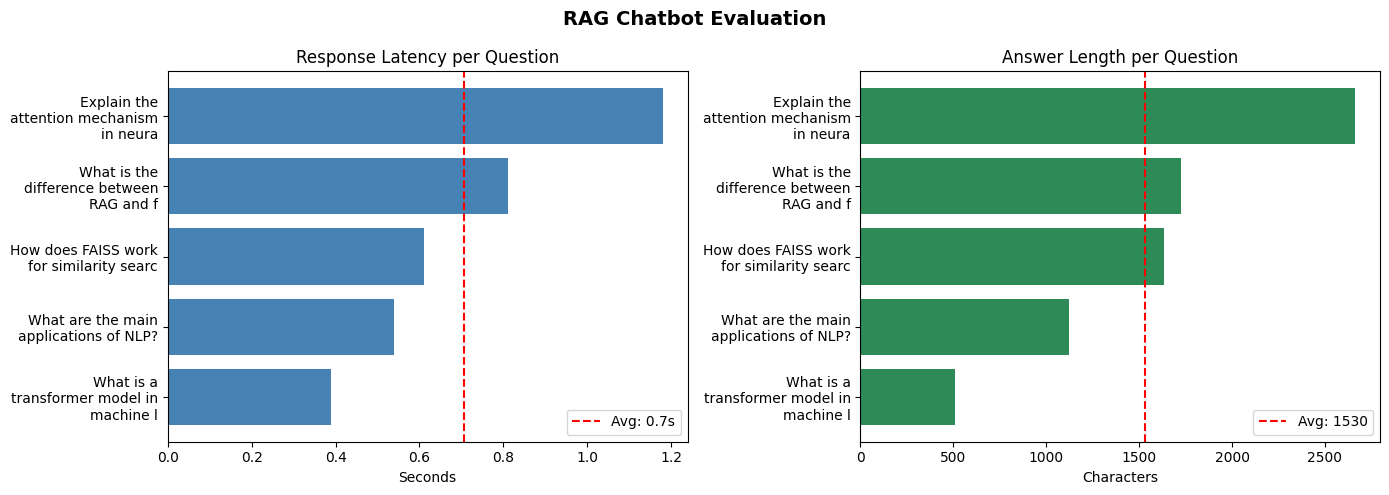

📊 Chart saved as evaluation_results.png


In [35]:
# ── Visualize results ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RAG Chatbot Evaluation", fontsize=14, fontweight="bold")

labels = [textwrap.fill(r["question"][:40], 20) for r in results]

# Latency chart
axes[0].barh(labels, [r["latency_s"] for r in results], color="steelblue")
axes[0].set_xlabel("Seconds")
axes[0].set_title("Response Latency per Question")
axes[0].axvline(avg_latency, color="red", linestyle="--", label=f"Avg: {avg_latency:.1f}s")
axes[0].legend()

# Answer length chart
axes[1].barh(labels, [r["answer_len"] for r in results], color="seagreen")
axes[1].set_xlabel("Characters")
axes[1].set_title("Answer Length per Question")
axes[1].axvline(avg_length, color="red", linestyle="--", label=f"Avg: {avg_length:.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as evaluation_results.png")

## 💾 Step 13: Save & Export

In [36]:
import json
from google.colab import files

# Save evaluation results to JSON
with open("eval_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Download files from Colab to your machine
files.download("app.py")              # Streamlit app
files.download("eval_results.json")   # Evaluation data
files.download("evaluation_results.png")  # Charts

print("✅ Files downloaded!")
print("\nTo re-run the Streamlit app locally:")
print("  1. pip install langchain langchain-community faiss-cpu streamlit")
print("  2. Set OPENAI_API_KEY environment variable")
print("  3. streamlit run app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!

To re-run the Streamlit app locally:
  1. pip install langchain langchain-community faiss-cpu streamlit
  2. Set OPENAI_API_KEY environment variable
  3. streamlit run app.py


In [37]:
%%writefile app.py
import os
import streamlit as st
from langchain_community.vectorstores import FAISS
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

st.set_page_config(page_title="RAG Chatbot", page_icon="🤖", layout="wide")
st.title("🤖 Context-Aware RAG Chatbot")
st.caption("Powered by LangChain + FAISS | Remembers conversation context")

with st.sidebar:
    st.header("⚙️ Configuration")
    openai_key = st.text_input("OpenAI API Key", type="password",
                               value=os.environ.get("OPENAI_API_KEY", ""))
    groq_key = st.text_input("Groq API Key", type="password",
                              value=os.environ.get("GROQ_API_KEY", ""),
                              help="Free at console.groq.com")
    top_k = st.slider("Retrieved chunks (k)", 2, 8, 4)
    temperature = st.slider("LLM Temperature", 0.0, 1.0, 0.2, step=0.05)
    show_sources = st.toggle("Show source documents", value=True)

    st.divider()
    if st.button("🗑️ Clear conversation"):
        st.session_state.messages = []
        st.session_state.store = {}
        st.rerun()

    st.divider()
    st.markdown("**About**")
    st.markdown("""
    This chatbot uses:
    - 🔍 **FAISS** vector search
    - 🧠 **Sliding window** memory
    - 📄 **Wikipedia** knowledge base
    - 🔗 **LangChain** orchestration
    """)

@st.cache_resource(show_spinner="Loading knowledge base...")
def load_chain(api_key, groq_api_key, k, temp):
    use_openai = bool(api_key)
    if use_openai:
        os.environ["OPENAI_API_KEY"] = api_key
        from langchain_openai import OpenAIEmbeddings, ChatOpenAI
        embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
        llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=temp, max_tokens=800)
    else:
        from langchain_community.embeddings import HuggingFaceEmbeddings
        from langchain_groq import ChatGroq
        if groq_api_key:
            os.environ["GROQ_API_KEY"] = groq_api_key
        embeddings = HuggingFaceEmbeddings(
            model_name="sentence-transformers/all-MiniLM-L6-v2"
        )
        llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=temp, max_tokens=512)

    vectorstore = FAISS.load_local(
        "faiss_index", embeddings, allow_dangerous_deserialization=True
    )
    retriever = vectorstore.as_retriever(
        search_type="mmr", search_kwargs={"k": k, "fetch_k": k * 2}
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a knowledgeable AI assistant. Answer accurately
using the provided context. If unsure, say so.

Context:
{context}"""),
        MessagesPlaceholder(variable_name="chat_history"),
        ("human", "{question}"),
    ])

    def format_docs(docs):
        return "\n\n".join(d.page_content for d in docs)

    rag_chain = (
        RunnablePassthrough.assign(
            context=lambda x: format_docs(retriever.invoke(x["question"]))
        )
        | prompt
        | llm
        | StrOutputParser()
    )
    return rag_chain

if "messages" not in st.session_state:
    st.session_state.messages = []
if "store" not in st.session_state:
    st.session_state.store = {}

SESSION_ID = "streamlit_session"

def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in st.session_state.store:
        st.session_state.store[session_id] = ChatMessageHistory()
    return st.session_state.store[session_id]

rag_chain = load_chain(openai_key, groq_key, top_k, temperature)

qa_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="question",
    history_messages_key="chat_history",
)

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

if prompt_input := st.chat_input("Ask anything about the knowledge base..."):
    st.session_state.messages.append({"role": "user", "content": prompt_input})
    with st.chat_message("user"):
        st.markdown(prompt_input)

    with st.chat_message("assistant"):
        with st.spinner("Thinking..."):
            answer = qa_chain.invoke(
                {"question": prompt_input},
                config={"configurable": {"session_id": SESSION_ID}}
            )
        st.markdown(answer)
        st.session_state.messages.append({"role": "assistant", "content": answer})

Overwriting app.py


In [ ]:
!streamlit run app.py &
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("🌐 App URL:", public_url)

2026-06-08 12:00:43.657 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.27.28:8501

/content/app.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
/content/app.py:54: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100% 103/103 [00:00<

---
## 📋 Summary

| Component | Technology Used |
|---|---|
| **Framework** | LangChain |
| **Corpus** | Wikipedia + Custom Text + PDF support |
| **Text Splitter** | RecursiveCharacterTextSplitter (500 chars, 100 overlap) |
| **Embeddings** | OpenAI text-embedding-3-small / HuggingFace MiniLM |
| **Vector Store** | FAISS (Maximal Marginal Relevance search) |
| **LLM** | OpenAI GPT-3.5-Turbo / Mistral-7B (HuggingFace) |
| **Memory** | ConversationBufferWindowMemory (k=5 turns) |
| **Chain** | ConversationalRetrievalChain |
| **Deployment** | Streamlit + ngrok tunnel |

### Key Design Decisions
- **MMR retrieval** ensures diverse, non-redundant context chunks
- **Window memory** prevents unbounded context growth while preserving recent history
- **Custom system prompt** anchors the LLM to retrieved context and reduces hallucinations
- **Source attribution** displayed in UI for transparency